In [ ]:
pip install ugot

In [1]:
import time
from ugot import ugot
got = ugot.UGOT()
got.initialize('192.168.1.166')
print("UGOT connected.")
got.play_audio_tts("Hello,how are you doing?", 0, False)
got.show_light_rgb_effect(0,255,0,3)
time.sleep(2)
got.turn_off_lights()

192.168.1.166:50051
UGOT connected.


In [ ]:
# OpenCV related import
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image,display
import os

## Session 7

1. create folders to store the images

In [2]:
import os
# create folder path
DATASET_FOLDER = "traffic_sign_dataset"
LEFT_FOLDER=os.path.join(DATASET_FOLDER,"LEFT")
RIGHT_FOLDER=os.path.join(DATASET_FOLDER,"RIGHT")
STOP_FOLDER=os.path.join(DATASET_FOLDER,"STOP")
NO_SIGN_FOLDER=os.path.join(DATASET_FOLDER,"NO_SIGN")

# create a real folder
os.makedirs(LEFT_FOLDER,exist_ok=True)
os.makedirs(RIGHT_FOLDER,exist_ok=True)
os.makedirs(STOP_FOLDER,exist_ok=True)
os.makedirs(NO_SIGN_FOLDER,exist_ok=True)

2. collect the images

Place the sign inside the green box.
Saved image1.


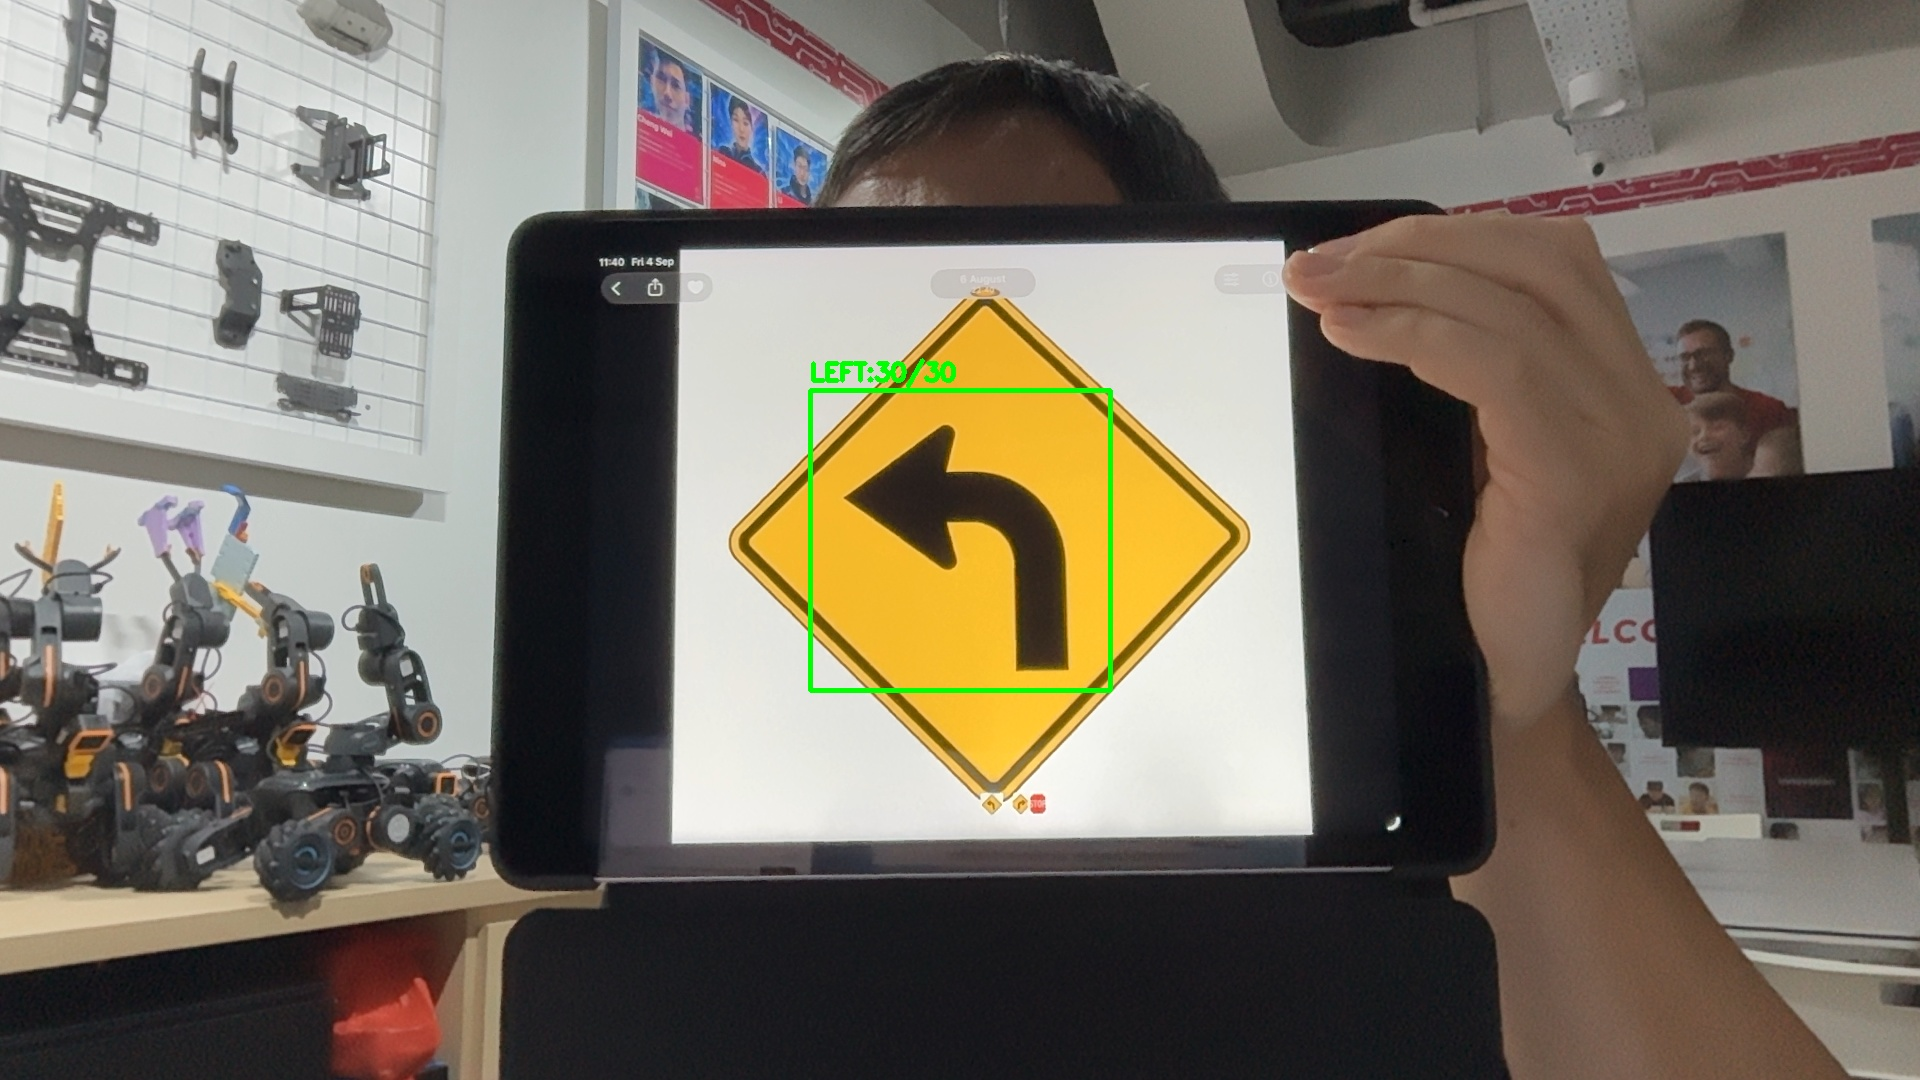

Saved image2.
Saved image3.
Saved image4.
Saved image5.
Saved image6.
Saved image7.
Saved image8.
Saved image9.
Saved image10.
Saved image11.
Saved image12.
Saved image13.
Saved image14.
Saved image15.
Saved image16.
Saved image17.
Saved image18.
Saved image19.
Saved image20.
Saved image21.
Saved image22.
Saved image23.
Saved image24.
Saved image25.
Saved image26.
Saved image27.
Saved image28.
Saved image29.
Saved image30.
Finished collecting30LEFT images.


In [19]:
import time
import cv2
import os
from IPython.display import Image,display

# choose which category to collect
save_folder = LEFT_FOLDER
class_name = "LEFT"

total_images = 30
save_interval=1


#open the laptop camera
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
time.sleep(1)

if not camera.isOpened():
    print("The camera is not opened.")
else:
    print(f"Collecting {class_name} images.")
    print("Place the sign inside the green box.")

    time.sleep(5)

    collected = 0
    last_save_time = 0
    handle = None

    while collected < total_images:
        frame_ok, frame = camera.read()

        if not frame_ok:
            print("The camera can not capture the image.")
            break
        # get the frame size
        frame_height,frame_width = frame.shape[:2]

        # create a 300*300 box in the center
        box_size = 300

        #calculate the top left corner
        x1 = (frame_width - box_size)//2
        y1 = (frame_height-box_size)//2
        # calculate the bottom right corner
        x2 = x1+ box_size
        y2 = y1+ box_size

        # crop the image inside the box
        scanning_area = frame[y1:y2,x1:x2]

        current_time = time.time()
        # save the image every 1 second
        if current_time - last_save_time >= save_interval:

            filename = os.path.join(save_folder,f"{class_name.lower()}_{collected}.jpg")
            saved_ok = cv2.imwrite(filename, scanning_area)

            if saved_ok:
                collected+=1
                last_save_time = current_time
                print(f"Saved image{collected}.")

        # draw a scanning box
        cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),3)

        # Show the number of collected images
        cv2.putText(frame,f"{class_name}:{collected}/{total_images}",(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,0),3)

        jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
        if jpeg_ok: # create the display area for the first time
            if handle is None:
                handle = display(Image(data=jpeg.tobytes()),display_id=True)
            else:
                handle.update(Image(data=jpeg.tobytes())) # update the same display area

        time.sleep(0.02)

    camera.release()
    print(f"Finished collecting{collected}{class_name} images.")


## Session 8

1. collect traffic signs

In [ ]:
import cv2
import time
import os
import glob
from IPython.display import display, Image


def collect_images(class_name, save_folder, total_images=30):
    save_interval = 1
    # Open the MacBook camera
    camera = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
    # Windows:
    # camera = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not camera.isOpened():
        print("The camera could not be opened.")
        camera.release()
        return
    collected = len(glob.glob(os.path.join(save_folder, "*.jpg")))
    target = collected + total_images

    print(f"Collecting {class_name} images.")
    print(f"The folder already has {collected} images.")
    print("Place the sign inside the green box.")

    time.sleep(3)

    last_save_time = 0
    failed_saves = 0
    handle = None

    while collected < target:
        frame_ok, frame = camera.read()
        if not frame_ok:
            print("The camera could not capture an image.")
            break

        # Get the frame size
        frame_height, frame_width = frame.shape[:2]

        # Create a 300 x 300 box in the centre.
        # The camera records at 1920 x 1080, so this box covers about one
        # sixth of the width. Every training image is cropped at this size.
        box_size = 300

        x1 = (frame_width - box_size) // 2
        y1 = (frame_height - box_size) // 2
        x2 = x1 + box_size
        y2 = y1 + box_size

        # Crop the image inside the box BEFORE the green box is drawn,
        # so the green box is never saved into the training picture
        scanning_area = frame[y1:y2, x1:x2]
        current_time = time.time()

        # Save one image every 1 second
        if current_time - last_save_time >= save_interval:

            filename = os.path.join(
                save_folder,
                f"{class_name.lower()}_{collected}.jpg"
            )
            saved_ok = cv2.imwrite(filename, scanning_area)

            if saved_ok:
                collected += 1
                last_save_time = current_time
                failed_saves = 0
                print(f"Saved image {collected}")

            else:
                # Give up instead of looping forever if the file cannot be saved
                failed_saves += 1
                last_save_time = current_time
                print("The image could not be saved.")

                if failed_saves >= 3:
                    print("Saving keeps failing. Check the folder, then try again.")
                    break
        # Draw the green scanning box
        cv2.rectangle( frame,(x1, y1),(x2, y2),(0, 255, 0),3)

        # Show the number of collected images
        cv2.putText(frame,f"{class_name}: {collected}/{target}",(x1, y1 - 15),cv2.FONT_HERSHEY_SIMPLEX,
            0.7,(0, 255, 0),2)

        # Show the live video in Jupyter Notebook
        jpeg_ok, jpeg = cv2.imencode(".jpg", frame)

        if jpeg_ok:
            if handle is None:
                handle = display(Image(data=jpeg.tobytes()),display_id=True)
            else:
                handle.update(Image(data=jpeg.tobytes()))

        time.sleep(0.03)

    camera.release()

    print(f"Finished. The folder now has {collected} {class_name} images.")
    print("Camera released.")

In [ ]:
collect_images("RIGHT",RIGHT_FOLDER, total_images=30)

In [ ]:
collect_images("STOP",STOP_FOLDER, total_images=30)

In [ ]:
collect_images("NO_SIGN",NO_SIGN_FOLDER, total_images=30)

2. check the dataset

In [20]:
import glob

LEFT_images = glob.glob(LEFT_FOLDER+ "/*.jpg")
RIGHT_images = glob.glob(RIGHT_FOLDER+ "/*.jpg")
STOP_images = glob.glob(STOP_FOLDER+ "/*.jpg")
NO_SIGN_images = glob.glob(NO_SIGN_FOLDER+ "/*.jpg")

print(f"LEFT:{len(LEFT_images)}")
print(f"RIGHT:{len(RIGHT_images)}")
print(f"STOP:{len(STOP_images)}")
print(f"NO_SIGN:{len(NO_SIGN_images)}")


LEFT:30
RIGHT:30
STOP:30
NO_SIGN:30


In [21]:
minimum_images = 28
dataset_ready = True

if len(LEFT_images)< minimum_images:
    print("LEFT needs more images.")
    dataset_ready = False

if len(RIGHT_images)< minimum_images:
    print("RIGHT needs more images.")
    dataset_ready = False

if len(STOP_images)< minimum_images:
    print("STOP needs more images.")
    dataset_ready = False

if len(NO_SIGN_images)< minimum_images:
    print("NO_SIGN needs more images.")
    dataset_ready = False

if dataset_ready:
    print("The dataset is ready for training.")
else:
    print("Please collect more images.")

The dataset is ready for training.


3. turn one picture into KNN number

In [22]:
import cv2
import time
import os
import glob
from IPython.display import display, Image
import numpy as np
# Define the images size for KNN
IMAGE_SIZE = 32
# Choose the KNN neighbours
k = 3
BOX_SIZE = 300
def prepare_image(image):
    # step 1: change the image to grayscale
    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    # step 2: make every image 32*32
    small_image = cv2.resize(gray,(IMAGE_SIZE,IMAGE_SIZE))
    # step 3: change the square into on long row
    pixel_row = small_image.flatten()
    # step 4: change the numbers to float32
    pixel_row = pixel_row.astype(np.float32)
    # step 5: change 0-255 into 0-1
    pixel_row = pixel_row/255.0
    return pixel_row
print(f"Prepare_image is ready, every picture will become {IMAGE_SIZE *IMAGE_SIZE} numbers.")

Prepare_image is ready, every picture will become 1024 numbers.


4. load the training images

In [23]:
if not dataset_ready:
    print("The dataset is not ready.")
else:
    training_data = []
    training_labels = []

    #LEFT = 0
    for filename in glob.glob(os.path.join(LEFT_FOLDER,"*.jpg")):
        image = cv2.imread(filename)

        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(0)

    #RIGHT = 1
    for filename in glob.glob(os.path.join(RIGHT_FOLDER,"*.jpg")):
        image = cv2.imread(filename)
    
        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(1)

    #STOP = 2
    for filename in glob.glob(os.path.join(STOP_FOLDER,"*.jpg")):
        image = cv2.imread(filename)
    
        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(2)

    #NO_SIGN = 3
    for filename in glob.glob(os.path.join(NO_SIGN_FOLDER,"*.jpg")):
        image = cv2.imread(filename)
    
        if image is not None:
            training_data.append(prepare_image(image))
            training_labels.append(3)

    #change the Python list into Numpy arrays for OpenCV
    training_data = np.array(training_data,dtype=np.float32)
    training_labels = np.array(training_labels,dtype=np.float32).reshape(-1,1)

    print(f"Training data shape:{training_data.shape}")
    print(f"Training labels shape:{training_labels.shape}")    

Training data shape:(120, 1024)
Training labels shape:(120, 1)


## Session 9

1. Train the KNN model

In [24]:
knn = cv2.ml.KNearest_create()

knn.train(training_data,cv2.ml.ROW_SAMPLE,training_labels)

print("KNN training is complete.")

KNN training is complete.


2. predict one picture

In [25]:
def predict_sign(image):
    pixel_row = prepare_image(image)

    # OpenCV wants one sample row
    pixel_row = pixel_row.reshape(1,-1)
    _,result,neighbours,distance = knn.findNearest(pixel_row,k)

    label = int(result[0][0])

    if label ==0:
        prediction = "LEFT"
    elif label ==1:
        prediction = "RIGHT"
    elif label ==2:
        prediction = "STOP"
    else:
        prediction = "NO_SIGN"
    return prediction

print("prediction_sign is ready.")


prediction_sign is ready.


3. KNN test without UGOT

The camera is on.


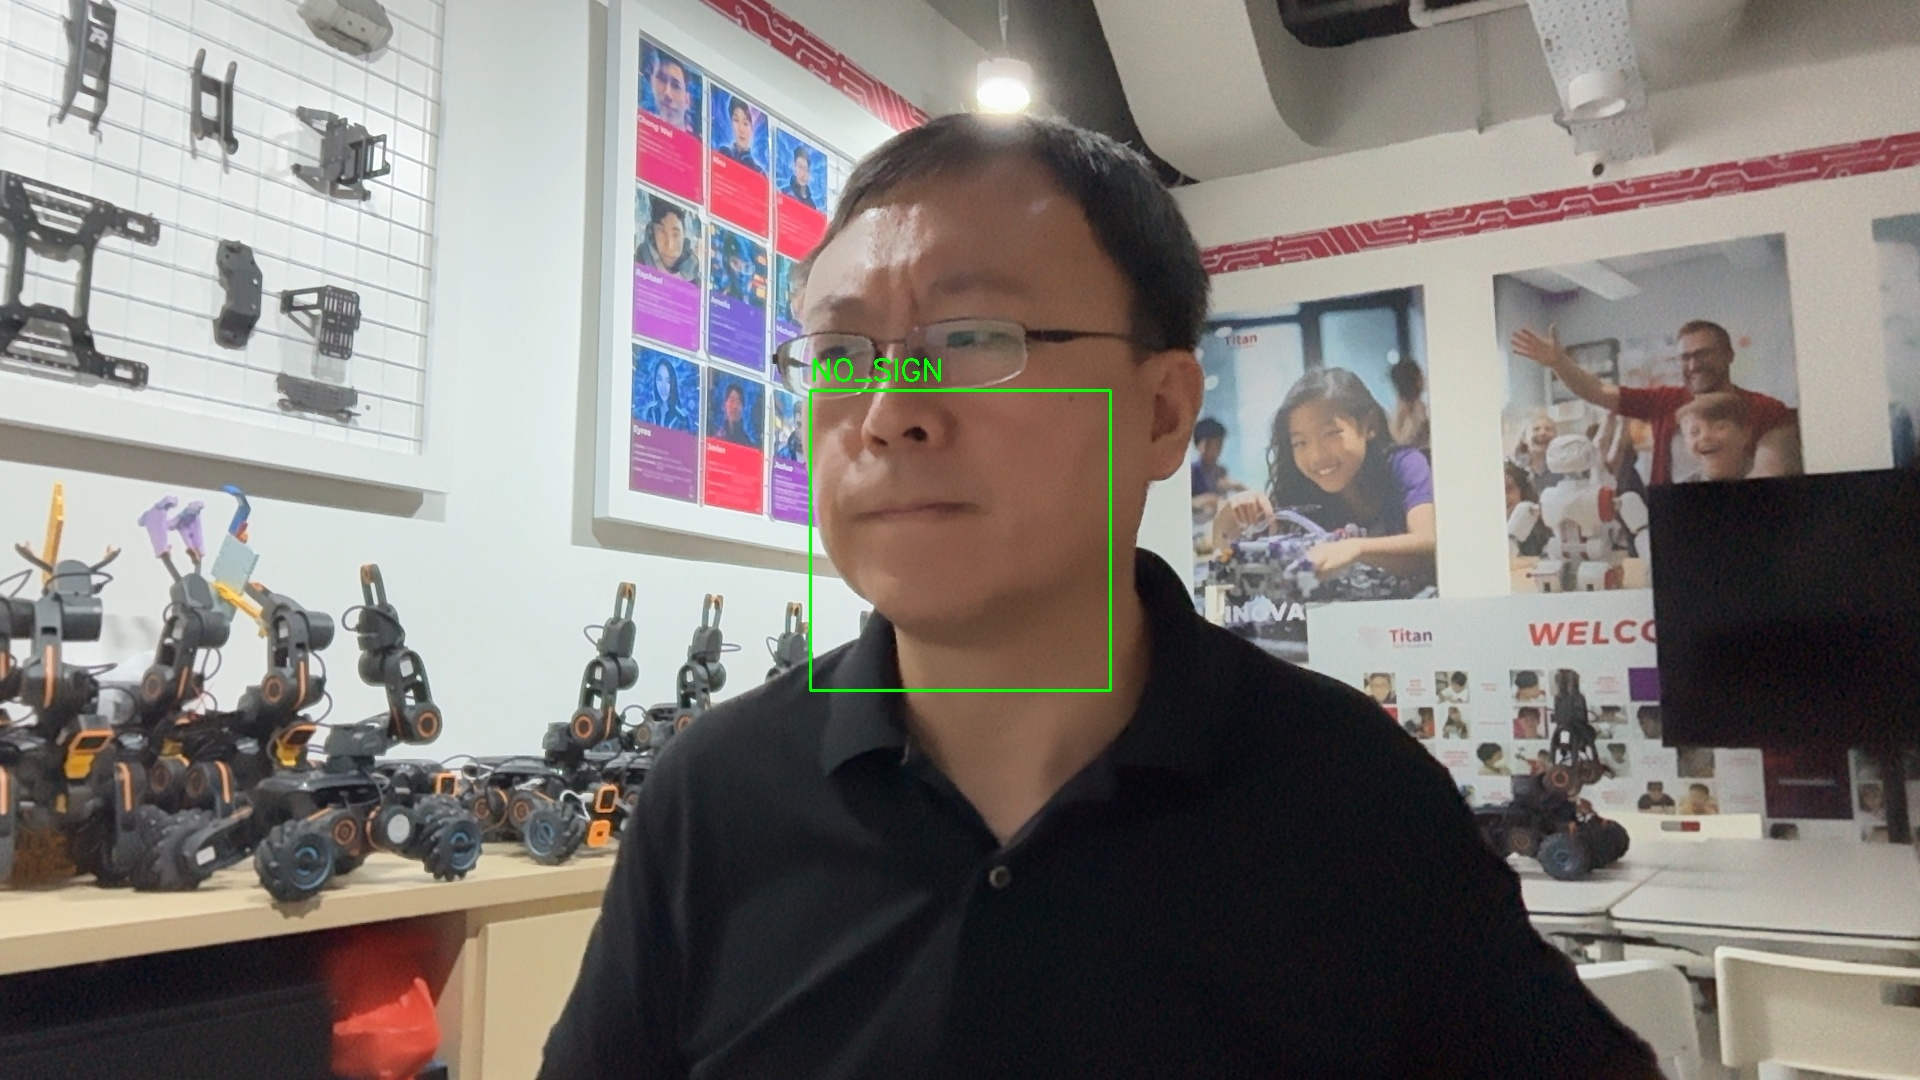

Test finished.


In [26]:
import time
camera = cv2.VideoCapture(0)
if not camera.isOpened():
    raise Exception("Cannot open the laptop camera.")
print("The camera is on.")

ok,picture_bgr = camera.read()
if not ok:
    raise Exception("No camera data.")

ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(picture_jpg.tobytes()),display_id=True)

start_time = time.time()
duration = 30

while time.time()-start_time< duration:
    ok,picture_bgr = camera.read()
    if not ok:
        continue

    #picture_bgr = cv2.flip(picture_bgr,1)
    BOX_SIZE = 300
    height,width = picture_bgr.shape[:2]
    x1 = width//2 - BOX_SIZE//2
    y1 = height//2 - BOX_SIZE//2
    x2 = x1+BOX_SIZE
    y2 = y1+BOX_SIZE

    crop = picture_bgr[y1:y2,x1:x2]
    prediction = predict_sign(crop)

    cv2.rectangle(picture_bgr,(x1,y1),(x2,y2),(0,255,0),2)
    cv2.putText(picture_bgr,prediction,(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(picture_jpg.tobytes()))

    time.sleep(0.1)

camera.release()
print("Test finished.")


## Session 10

1. final presentation

In [ ]:
# OpenCV related import
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image,display
import os

2.UGOT control with KNN

The camera is on.


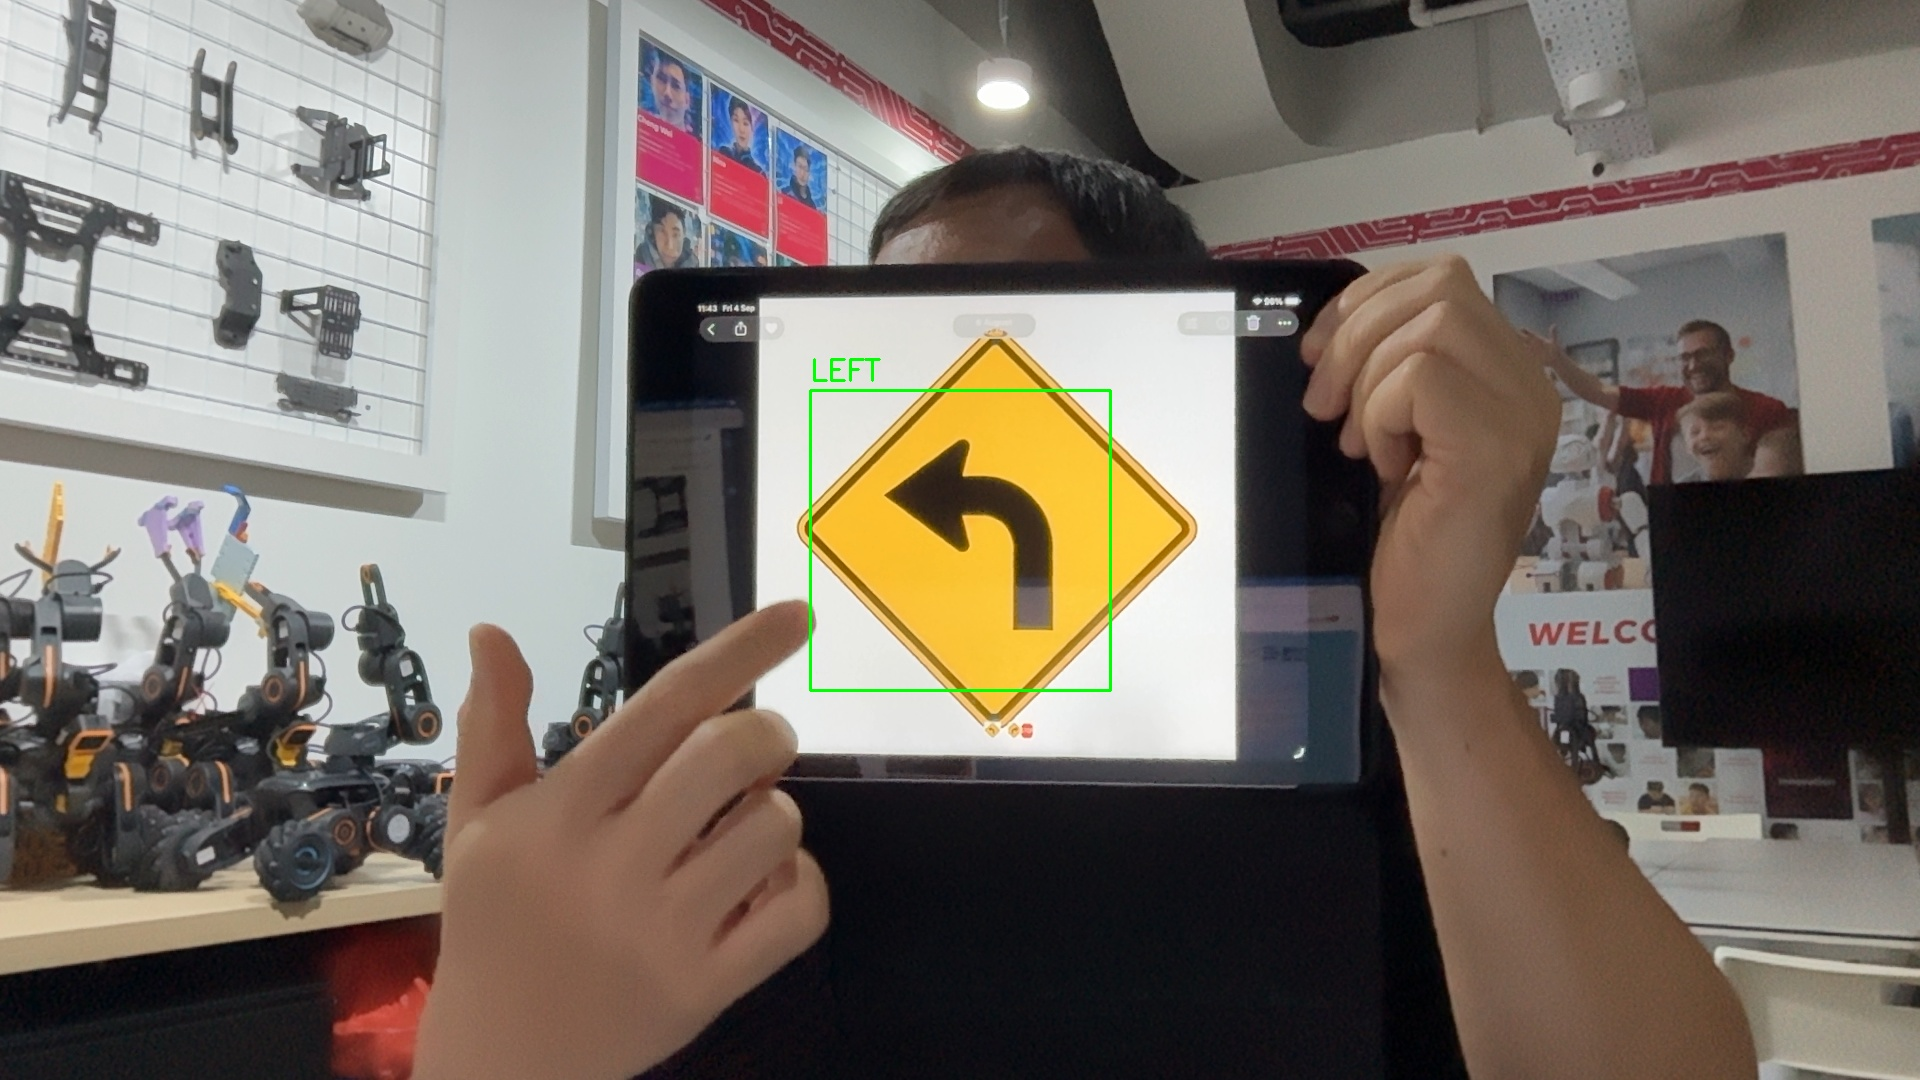

In [ ]:
# time limits

camera = cv2.VideoCapture(0)
if not camera.isOpened():
    raise Exception("Cannot open the laptop camera.")
print("The camera is on.")

ok, picture_bgr = camera.read()
if not ok:
    raise Exception("No camera data.")

ok, picture_jpg = cv2.imencode(".jpg", picture_bgr)
handle = display(Image(picture_jpg.tobytes()), display_id=True)

forward_speed = 15      # cm/s
turn_speed = 30          # deg/s
CONFIRM_FRAMES = 3       # require the same prediction this many times in a row

last_prediction = "NO_SIGN"
confirm_count = 0

start_time = time.time()
duration = 60

while time.time() - start_time < duration:
    ok, picture_bgr = camera.read()
    if not ok:
        continue

    # picture_bgr = cv2.flip(picture_bgr, 1)

    height, width = picture_bgr.shape[:2]
    x1 = width//2 - BOX_SIZE//2
    y1 = height//2 - BOX_SIZE//2
    x2 = x1 + BOX_SIZE
    y2 = y1 + BOX_SIZE

    crop = picture_bgr[y1:y2,x1:x2]
    prediction = predict_sign(crop)

    cv2.rectangle(picture_bgr, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(picture_bgr, prediction, (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    # debounce: only act once the same prediction repeats
    if prediction == last_prediction:
        confirm_count += 1
    else:
        confirm_count = 1
        last_prediction = prediction

    if confirm_count == CONFIRM_FRAMES:
        if prediction == "NO_SIGN":
            got.mecanum_move_speed(0, forward_speed)
        elif prediction == "LEFT":
            got.mecanum_stop()
            got.mecanum_turn_speed(2, turn_speed)
        elif prediction == "RIGHT":
            got.mecanum_stop()
            got.mecanum_turn_speed(3, turn_speed)
        elif prediction == "STOP":
            got.mecanum_stop()

    ok, picture_jpg = cv2.imencode(".jpg", picture_bgr)
    if ok:
        handle.update(Image(picture_jpg.tobytes()))

    time.sleep(0.1)

got.mecanum_stop()
camera.release()
print("Test finished.")